### Simulation Results - Poster Test

In [1]:
import numpy as np, pandas as pd
import importlib
import test_WTM as wtm, watts_model as nwm
import gudhi_persistence as gp
import utilsA1 as utils
import os, networkx as nx
from sklearn.decomposition import PCA

from lifelines import CoxTimeVaryingFitter


In [38]:
importlib.reload(wtm)
importlib.reload(nwm)
importlib.reload(utils)
importlib.reload(gp)

PATH = os.getcwd()
output_file = "FLCRM"
params_temp_list = {'num_nodes': 100, 'num_neighbor_nodes': 3,
                    'total_random_edges': 40, 'distance_threshold': 20, 'weighted': True,
                    'ngeo_placement': 'random.choice', 'n_seeds': 2, 'node_active_threshold': 0.1,
                    'upper_weight_limit': 5,  'skew_power': 2, 'seed_cluster_distance': 20,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'all_combinations', 'calculate_representation': True,
                    'bandwidth': 0.1, 'num_landscapes': 3, 'resolution': 50}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) - 2

# df, activation_results = wtm.main_sims(params_list=[params_temp_list],
#                    output_file=output_file, save_files=False)

#### Homology Representation

In [47]:

importlib.reload(gp)
importlib.reload(utils)
importlib.reload(nwm)
importlib.reload(wtm)

params_temp_list['seeding_method'] = 'cluster_seeding'
params_temp_list['calculate_representation'] = bool(False)
graph, seed_nodes = nwm.simulate_contagion_map(params=params_temp_list)
adjacency_matrix = nx.to_numpy_array(graph, dtype=float, weight=None)
weight_0 = nx.to_numpy_array(graph, weight='weight', nonedge=1e9)

graph, snapshots, activation_times, results = nwm.simulate_contagion_realization(graph = graph, init_seeds = seed_nodes[0], params = params_temp_list,
max_steps = 100, adjacency_matrix = adjacency_matrix, weight_0 = weight_0)

utils.visualize_step_animation_new(G=graph, snapshots=snapshots,
                         output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))
print(f"Graphs @: file:///C:/Users/sranasin/PycharmProjects/NetworkModels/Project1/A1/Outputs/{output_file}.html")
print(activation_times)

Graphs @: file:///C:/Users/sranasin/PycharmProjects/NetworkModels/Project1/A1/Outputs/FLCRM.html
[2 1 0 3 2 3 4 3 4 5 4 4 5 5 3 5 5 4 5 5 5 4 4 5 5 5 5 4 5 4 3 4 4 4 5 5 5
 6 6 5 6 5 6 6 5 5 5 4 5 4 5 6 5 6 5 4 5 4 3 4 3 2 3 2 1 0 1 2 3 4 3 4 4 4
 5 5 5 4 5 6 5 6 6 5 6 5 6 6 6 5 5 5 4 4 4 3 3 3 2 1]


In [37]:
for u, v, d in graph.edges(data=True):
    print(d)

{'type': 'geometric', 'weight': np.float64(1.0)}
{'type': 'geometric', 'weight': np.float64(1.0)}
{'type': 'geometric', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(2.0)}
{'type': 'geometric', 'weight': np.float64(2.0)}
{'type': 'what', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(2.0)}
{'type': 'geometric', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(2.0)}
{'type': 'what', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(2.0)}
{'type': 'geometric', 'weight': np.float64(0.0)}
{'type': 'geometric', 'weight': np.float64(1.0)}
{'type': 'geometric', 'weight': np.float64(2.0)}
{'type': 'geometric', 'weight'

In [4]:
importlib.reload(gp)
importlib.reload(nwm)
betti_nums, persistence, persistence_intervals_for_diagram = gp.compute_persistence(graph=graph, activation_times=activation_times, max_dim=2)

In [5]:
print(persistence)

[[list([(0.0, inf), (0.0, inf)]) list([]) list([])]
 [list([(0.0, inf), (0.0, inf)]) list([]) list([])]
 [list([(2.0, inf), (2.0, inf), (2.0, inf), (0.0, inf), (0.0, inf)])
  list([]) list([])]
 [list([(3.0, inf), (3.0, inf), (0.0, inf), (0.0, inf), (2.0, inf), (2.0, inf), (2.0, inf)])
  list([]) list([])]
 [list([(4.0, inf), (0.0, inf), (0.0, inf), (2.0, inf), (2.0, inf), (2.0, inf), (3.0, inf), (3.0, 4.0)])
  list([]) list([])]
 [list([(2.0, inf), (2.0, inf), (0.0, inf), (2.0, inf), (0.0, inf), (3.0, 5.0), (3.0, 4.0), (4.0, 5.0)])
  list([]) list([])]
 [list([(6.0, inf), (2.0, inf), (2.0, inf), (0.0, inf), (2.0, inf), (0.0, inf), (3.0, 5.0), (3.0, 4.0), (4.0, 5.0)])
  list([]) list([])]
 [list([(2.0, inf), (2.0, inf), (0.0, inf), (0.0, inf), (6.0, inf), (2.0, 7.0), (3.0, 5.0), (3.0, 4.0), (4.0, 5.0)])
  list([]) list([])]
 [list([(2.0, inf), (0.0, inf), (0.0, 8.0), (2.0, 8.0), (2.0, 7.0), (3.0, 5.0), (6.0, 8.0), (3.0, 4.0), (4.0, 5.0)])
  list([]) list([])]
 [list([(9.0, inf), (9.0, 

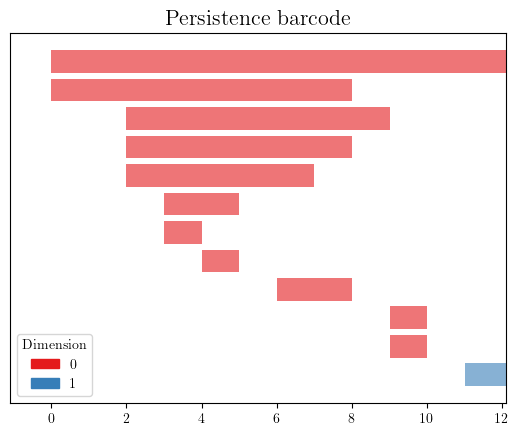

In [6]:
gp.persistence_barcodes(persistence_intervals_for_diagram)

In [ ]:
importlib.reload(gp)
# test_pers_0 = np.array([(birth, death) for dim, intervla in persistence if dim == 0])
L, I, E, params = gp.persistence_representation_t(persistence, num_landscapes=4)

# landscape
# plt.plot(df.loc[row_id, 'L_0'][:resolution])
# plt.plot(df.loc[row_id, 'L_1'][resolution: resolution*2])
# plt.plot(df.loc[row_id, 'L_2'][resolution*2:resolution*3])
# plt.title("Landscape")
# plt.show()

In [ ]:
type(L[0][0])

In [ ]:
resolution = params['resolution']
timestep = 7
test_resolution = 10
plt.plot(L[timestep][0][:resolution])
plt.plot(L[timestep][0][resolution: resolution*2])
plt.plot(L[timestep][0][resolution*2: resolution*3])
# plt.plot(L[0][resolution*2:resolution*3])
plt.title("Landscape")
plt.show()

In [ ]:
gp.betti_nums_over_time(betti_over_time=betti_numbers)

In [ ]:
gp.persistence_diagram(persistence_intervals_for_diagram)

In [ ]:

gp.persistence_barcodes(persistence_intervals_for_diagram)

#### Persistence Images / Landscapes

In [ ]:
row_id = 12
resolution = params_temp_list['resolution']
plt.imshow(np.flip(np.reshape(df.loc[row_id, 'I_0'], [resolution,resolution]), 0))
plt.title("Persistence Image")
plt.show()

In [ ]:
plt.plot(df.loc[row_id, 'L_0'][:resolution])
plt.plot(df.loc[row_id, 'L_1'][resolution: resolution*2])
plt.plot(df.loc[row_id, 'L_2'][resolution*2:resolution*3])
plt.title("Landscape")
plt.show()

### Test Persistent Diagram Importance in PCA

In [4]:
import random
import pandas as pd
import numpy as np, networkx as nx, gudhi_persistence as gp, watts_model as nwm, matplotlib.pyplot as plt, utilsA1 as utils
import os, importlib

from sklearn.decomposition import PCA
from lifelines import CoxTimeVaryingFitter


In [5]:
num_samples = 40

params_list = []
for _ in range(num_samples):
    num_nodes = random.choice([30])
    weighted = True
    n_seeds = random.choice([1, 2])
    node_active_threshold = random.choice([0.02, 0.025, 0.03, 0.1])
    num_neighbor_nodes = random.choice([1, 3, 4])
    distance_threshold = random.randint(num_neighbor_nodes + 1, num_neighbor_nodes + 2)
    total_random_edges = random.choice([ 20, 30, 40, 60])
    upper_weight_limit = random.randint(10, 20)
    skew_power = random.randint(2, 4)
    seed_cluster_distance = random.choice([10, 15, 20, 25])
    ngeom_edges_in_persistence = False
    max_persistence_dim = 2
    threshold_sum = sum(range(num_nodes))
    seeding_method = 'all_combinations'
    ngeo_placement = 'random.choice'
    calculate_representation = True

    param = {
            'num_nodes': num_nodes,  # fixed
            'num_neighbor_nodes': num_neighbor_nodes,
            'total_random_edges': total_random_edges,
            'distance_threshold': distance_threshold,
            'weighted': weighted,
            'ngeo_placement': ngeo_placement,  # other 'ngeo_per_node'
            'n_seeds': n_seeds,
            'node_active_threshold': node_active_threshold,
            'upper_weight_limit': upper_weight_limit,
            'skew_power': skew_power,
            'seed_cluster_distance': seed_cluster_distance,
            'ngeom_edges_in_persistence': ngeom_edges_in_persistence,
            'max_persistence_dim': max_persistence_dim,
            'threshold_sum': threshold_sum,
            'seeding_method': seeding_method,
            'calculate_representation': calculate_representation,
            'bandwidth': 0.4
        }

    params_list.append(param)

In [6]:
param_df = pd.DataFrame(params_list)
param_df

,num_nodes,num_neighbor_nodes,total_random_edges,distance_threshold,weighted,ngeo_placement,n_seeds,node_active_threshold,upper_weight_limit,skew_power,seed_cluster_distance,ngeom_edges_in_persistence,max_persistence_dim,threshold_sum,seeding_method,calculate_representation,bandwidth
0,30,4,60,5,True,random.choice,2,0.030,13,2,25,False,2,435,all_combinations,True,0.4
1,30,3,30,4,True,random.choice,1,0.020,19,4,20,False,2,435,all_combinations,True,0.4
2,30,1,40,3,True,random.choice,2,0.030,18,2,15,False,2,435,all_combinations,True,0.4
3,30,4,60,5,True,random.choice,1,0.025,15,4,20,False,2,435,all_combinations,True,0.4
4,30,4,20,5,True,random.choice,2,0.025,14,3,15,False,2,435,all_combinations,True,0.4
5,30,4,60,5,True,random.choice,2,0.100,19,4,20,False,2,435,all_combinations,True,0.4
6,30,4,40,6,True,random.choice,2,0.025,18,2,25,False,2,435,all_combinations,True,0.4
7,30,4,40,6,True,random.choice,1,0.030,10,2,20,False,2,435,all_combinations,True,0.4
8,30,3,60,4,True,random.choice,2,0.025,10,2,15,False,2,435,all_combinations,True,0.4
9,30,3,20,5,True,random.choice,2,0.025,17,2,20,False,2,435,all_combinations,True,0.4


In [7]:
importlib.reload(nwm)
importlib.reload(gp)

# PATH = os.getcwd()
# output_file = 'FLCRM_test'
# output_file_path = os.path.join(PATH, 'Outputs', f"{output_file}.html")
df_temp, activation_results = nwm.main_sims(params_list=params_list, save_files=False)

Simulating Contagion Map for simulation: 0/40
Simulating Contagion Map for simulation: 1/40
Simulating Contagion Map for simulation: 2/40
Simulating Contagion Map for simulation: 3/40
Simulating Contagion Map for simulation: 4/40
Simulating Contagion Map for simulation: 5/40
Simulating Contagion Map for simulation: 6/40
Simulating Contagion Map for simulation: 7/40
Simulating Contagion Map for simulation: 8/40
Simulating Contagion Map for simulation: 9/40
Simulating Contagion Map for simulation: 10/40
Simulating Contagion Map for simulation: 11/40
Simulating Contagion Map for simulation: 12/40
Simulating Contagion Map for simulation: 13/40
Simulating Contagion Map for simulation: 14/40
Simulating Contagion Map for simulation: 15/40
Simulating Contagion Map for simulation: 16/40
Simulating Contagion Map for simulation: 17/40
Simulating Contagion Map for simulation: 18/40
Simulating Contagion Map for simulation: 19/40
Simulating Contagion Map for simulation: 20/40
Simulating Contagion Ma

In [5]:
df_temp.shape

(47323, 39)

In [8]:
# keep only realizations that have at least one row with state == 1
df_temp = df_temp[df_temp.groupby(['simulation_id', 'realization_id'])['state'].transform('max') == 1]
df_temp = df_temp[df_temp.groupby(['simulation_id', 'realization_id'])['state'].cumsum() <= 1]

In [9]:
# Define the list of front columns in desired order
front_columns = [
    "simulation_id", "realization_id", "time", "state",
    "node_active_threshold", "num_nodes", "num_neighbor_nodes",
    "total_random_edges", "num_active_nodes", "active_nodes"]

suffix_columns = [f"{prefix}_{i}" for prefix in ['H', 'L', 'I', 'E'] for i in range(3)]
all_columns = list(df_temp.columns)


middle_columns = [col for col in all_columns if col not in front_columns + suffix_columns]
df_temp = df_temp[front_columns + middle_columns + suffix_columns]
df_temp.drop(columns = suffix_columns, inplace=False).head(10)

,simulation_id,realization_id,time,state,node_active_threshold,num_nodes,num_neighbor_nodes,total_random_edges,num_active_nodes,active_nodes,...,seed_cluster_distance,ngeom_edges_in_persistence,max_persistence_dim,threshold_sum,seeding_method,calculate_representation,bandwidth,average_weight_per_edge,total_geo_edges,total_non_geo_edges
0,0,0,0,0,0.03,30,4,60,2,"[0, 1]",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0
1,0,0,1,0,0.03,30,4,60,6,"[0, 1, 6, 22, 8, 27]",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0
2,0,0,2,0,0.03,30,4,60,18,"[0, 1, 4, 5, 6, 7, 8, 10, 12, 15, 16, 18, 19, ...",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0
3,0,0,3,0,0.03,30,4,60,28,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0
4,0,0,4,1,0.03,30,4,60,30,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0
5,0,1,0,0,0.03,30,4,60,2,"[0, 2]",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0
6,0,1,1,0,0.03,30,4,60,9,"[0, 2, 3, 14, 15, 19, 20, 22, 28]",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0
7,0,1,2,0,0.03,30,4,60,23,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 12, 13, 14, 15, 16...",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0
8,0,1,3,0,0.03,30,4,60,29,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0
9,0,1,4,1,0.03,30,4,60,30,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,25,False,2,435,all_combinations,True,0.4,4.6,60,0


In [10]:
# df = df_temp[df_temp['state'] == 1]
df = df_temp
print(df.shape)
# df.drop(columns = suffix_columns,inplace=False).head(5)

(44000, 39)


In [11]:
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

n_components = 5

df_pca = df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2',
             'node_active_threshold', 'num_neighbor_nodes', 'total_random_edges', 'seed_cluster_distance', 'n_seeds', 'upper_weight_limit', 'skew_power']].copy()
# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return
    X = np.vstack(valid_df[feature_col].values)
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")

    pca_cols = [f"{prefix}_PC{i+1}" for i in range(X_pca.shape[1])]

    temp = valid_df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
    temp[pca_cols] = X_pca

    global df_pca
    df_pca = df_pca.merge(temp, on=['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2'], how='left')


In [12]:

for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Explained variance ratio: [0.97875356 0.98623728 0.99263715 0.99611173 0.99815302]
Skipping L_1 — no valid data.
Skipping L_2 — no valid data.
Explained variance ratio: [1. 1. 1. 1. 1.]
Skipping I_1 — no valid data.
Skipping I_2 — no valid data.


In [13]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["simulation_id", "realization_id", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["simulation_id", "realization_id"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])


ordered_cols = ["id", "start", "stop", "state"] + landscape_cols + image_cols + essentials_cols + [ 'node_active_threshold',
                                                                                                    'num_neighbor_nodes', 'total_random_edges', 'seed_cluster_distance', 'n_seeds', 'upper_weight_limit', 'skew_power']
df_pca['id'] = df['simulation_id'].astype(str) + "_" + df['realization_id'].astype(str) # + df['time'].astype(str)

df_pca = df_pca[ordered_cols]
df_pca.head(10)

C:\Users\sranasin\AppData\Local\Temp\ipykernel_14656\4147491483.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,id,start,stop,state,L_0_PC1,L_0_PC2,L_0_PC3,L_0_PC4,L_0_PC5,I_0_PC1,...,E_0,E_1,E_2,node_active_threshold,num_neighbor_nodes,total_random_edges,seed_cluster_distance,n_seeds,upper_weight_limit,skew_power
0,0_0,0,1.0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0,0,0,0.03,4,60,25,2,13,2
1,0_0,1,2.0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0,0,0,0.03,4,60,25,2,13,2
2,0_0,2,3.0,0,5.964118e-13,2.233456e-16,4.501607e-16,-4.100453e-16,2.518602e-16,-5.448109e-12,...,2,0,0,0.03,4,60,25,2,13,2
3,0_0,3,4.0,0,5.964118e-13,2.233456e-16,4.501607e-16,-4.100453e-16,2.518602e-16,-5.448109e-12,...,2,0,0,0.03,4,60,25,2,13,2
4,0_0,4,5.0,1,5.964118e-13,2.233456e-16,4.501607e-16,-4.100453e-16,2.518602e-16,-5.448109e-12,...,2,0,0,0.03,4,60,25,2,13,2
5,0_1,0,1.0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0,0,0,0.03,4,60,25,2,13,2
6,0_1,1,2.0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0,0,0,0.03,4,60,25,2,13,2
7,0_1,2,3.0,0,5.964118e-13,2.233456e-16,4.501607e-16,-4.100453e-16,2.518602e-16,-5.448109e-12,...,2,0,0,0.03,4,60,25,2,13,2
8,0_1,3,4.0,0,5.964118e-13,2.233456e-16,4.501607e-16,-4.100453e-16,2.518602e-16,-5.448109e-12,...,2,0,0,0.03,4,60,25,2,13,2
9,0_1,4,5.0,1,5.964118e-13,2.233456e-16,4.501607e-16,-4.100453e-16,2.518602e-16,-5.448109e-12,...,2,0,0,0.03,4,60,25,2,13,2


### Time-Varying FLCRM

In [ ]:
df_pca.drop(columns = ['E_1', 'E_2'], inplace=True)

ctv = CoxTimeVaryingFitter()
ctv.fit(df_pca, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()

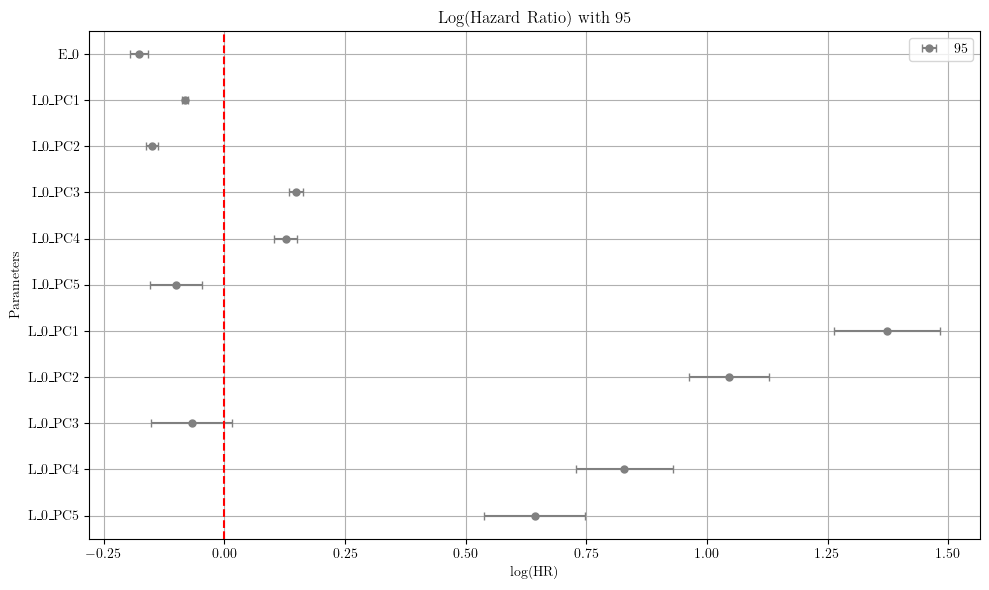

In [55]:
# sort teh values by param_ index name
param_names = ctv.params_.index
log_HR_values = ctv.params_.values
standard_errors = ctv.standard_errors_.values
df_plot = pd.DataFrame({
    'param_name': param_names,
    'log(HR)': log_HR_values,
    'std_error': standard_errors
})
sorted_df = df_plot.sort_values(by='param_name', ascending=False)


# re-create the erros bars from values
z_value = 1.96
sorted_df['lower_CI'] = sorted_df['log(HR)'] - z_value * sorted_df['std_error']
sorted_df['upper_CI'] = sorted_df['log(HR)'] + z_value * sorted_df['std_error']

# plot please
plt.figure(figsize=(10, 6))

plt.errorbar( sorted_df['log(HR)'], sorted_df['param_name'],
    xerr=[sorted_df['log(HR)'] - sorted_df['lower_CI'],
          sorted_df['upper_CI'] - sorted_df['log(HR)']], fmt='o', color='gray', markersize=5, capsize=3, label='95% CI')

plt.axvline(x=0, color = 'r', linestyle = '--')
plt.xlabel('log(HR)')
plt.ylabel('Parameters')
plt.title('Log(Hazard Ratio) with 95% Confidence Intervals (Rotated)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

<Axes: xlabel='log(HR) (95% CI)'>

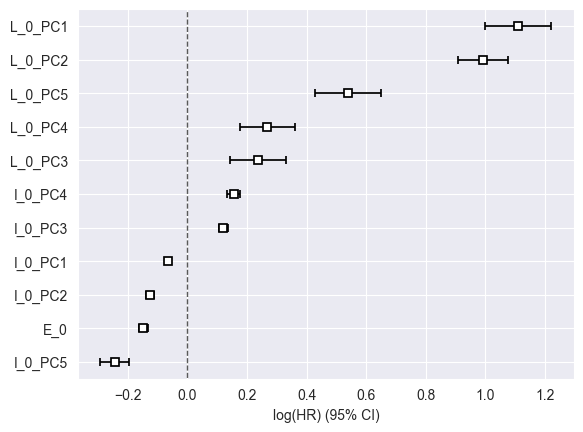

In [19]:
ctv.plot()

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter

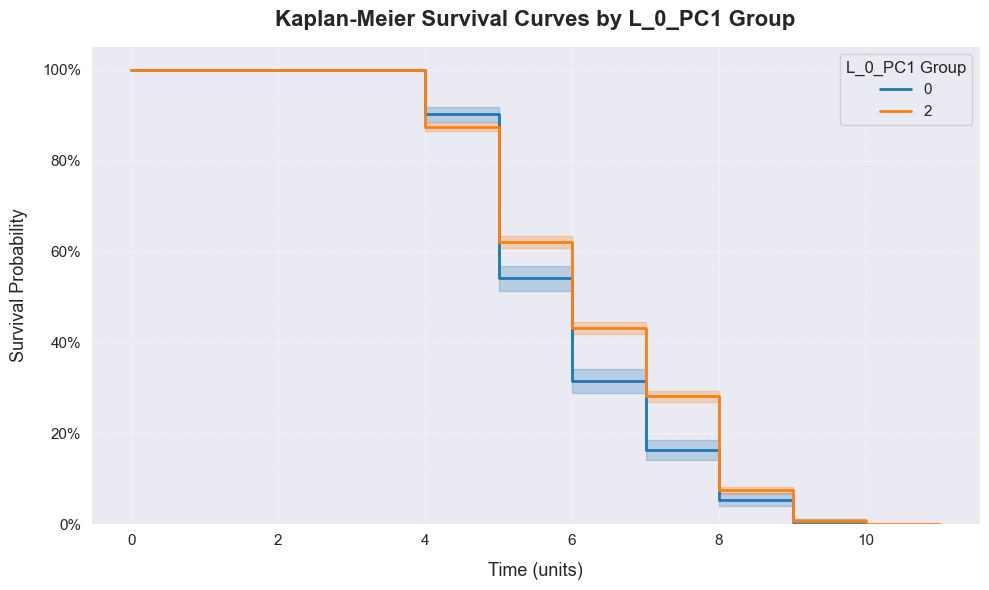

In [20]:
km_data = df_pca.sort_values("stop").groupby("id").last().reset_index()
fig, ax = plt.subplots(figsize=(10, 6))

for group, gdf in km_data.groupby("E_0"):
    kmf = KaplanMeierFitter()
    kmf.fit(gdf["stop"], event_observed=gdf["state"], label=str(group))
    kmf.plot_survival_function(
        ax=ax,
        ci_show=True,       # confidence interval shading
        linewidth=2,
    )

# Titles and axis labels
ax.set_title("Kaplan-Meier Survival Curves by L_0_PC1 Group",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Time (units)", fontsize=13, labelpad=10)
ax.set_ylabel("Survival Probability", fontsize=13, labelpad=10)

# Axis formatting
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.tick_params(axis="both", labelsize=11)

# Legend
ax.legend(
    title="L_0_PC1 Group",
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    loc="upper right",
)

# Clean grid
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("km_curve.png", dpi=300, bbox_inches="tight")  # high-res export
plt.show()